- 3.7596%  - Lablaws yeld for bond CA53947ZAC10 with maturity 11/8/2027 and coupon payment date on 5/8/2025 , tiwce a yr  - https://markets.businessinsider.com/bonds/6_850-loblaw-companies-bond-2032-ca53947zas61?miRedirects=1
- 3.083% - avg 4 year yield rates from the bonds chosen in Asmt one for the Canadian Govt bonds and form this website 
- 2.726% - this is the current estimates for the yield curve for 4 year bond froom this website, https://www.worldgovernmentbonds.com/country/canada/
- spread based on previous yield estimates

## Loblaw Companies Ltd Credit Risk Assesment 



---

### Bond Valuation and Default Models

---

Let \( q_i \) be the probability that a cashflow occurs. We can write for a bond:

$$
\textbf{Value} = \sum_{i=1}^{n} p_i \cdot e^{-r_i t_i} \cdot q_i
$$

Define the **hazard rate**:

$$
\textbf{h}_i = \frac{-\log(q_i)}{t_i}
$$

Cashflow valuation with hazard rate:

$$
\textbf{Value} = \sum_{i=1}^{n} p_i \cdot e^{-(r_i + h_i)t_i}
$$

Assume:

$$
\Pr(\text{Solvent at } t_{i+1} \mid \text{Solvent at } t_i) = q
$$

which implies \( q_i = q^{t_i} \), leading to a **constant spread**:

$$
h_i = h = -\log(q)
$$

Transition probability matrix:

|        | **Solvency** | **Default** |
|--------|--------------|-------------|
| **Solvency** | 0.9845 | 0.0155 |
| **Default** | 0      | 1      |

Value of bond with **recovery** rate \( 0 \leq R \leq 1 \):

$$
\textbf{V} = Ne^{-r}q + R \cdot Ne^{-r}(1 - q)
$$

Spread-adjusted value:

$$
\textbf{V} = Ne^{-(r + h)}
$$

Solving for probability of solvency:

$$
\textbf{q} = \frac{e^{-h} - R}{1 - R}
$$

---

### Merton Model for Corporate Debt and Equity

---

**Equity value at maturity**:

$$
\textbf{S}_T = \max(V_T - K, 0)
$$

**Debt value at maturity**:

$$
\textbf{B}_T = V_T - \max(V_T - K, 0) = \min(V_T, K)
$$

where \( V_T \) is the firm's **asset value**, \( K \) is **liabilities**, and \( S_T \) is **equity**.

Assume firm assets follow **geometric Brownian motion**:

$$
dV = \mu V \, dt + \sigma V \, dz
$$

Using the **Black-Scholes formula**:

$$
\textbf{S} = V N(d_1) - K e^{-r\tau} N(d_2)
$$
where $\tau$ = (T - t )
$$
\textbf{B} = K e^{-r\tau} N(d_2) + V [1 - N(d_1)]
$$

Definitions of \( d_1 \) and \( d_2 \):

$$
d_1 = \frac{\ln(V / (K e^{-r\tau}))}{\sigma \sqrt{\tau}} + \frac{\sigma \sqrt{\tau}}{2}
$$

$$
d_2 = d_1 - \sigma \sqrt{\tau}
$$

From the equations, \( N(-d_2) \) gives the **probability of default**.

---

### Volatility and Hedge Ratios - Using Black-Scholes Calculator 

---

From the **hedge ratio**:

$$
d\textbf{S} = \frac{\partial S}{\partial V} dV
$$

Relation between **volatilities** of equity and assets:

$$
\sigma_{\textbf{S}} S = \sigma_{\textbf{V}} V \frac{\partial S}{\partial V}
$$

Fixed-point expression for **asset volatility**:

$$
\sigma_{\textbf{V}} = \sigma_{\textbf{S}} \frac{S \, \partial V}{V \, \partial S}
$$


A Black-scholes Calculator is used to find the asset volatility via iterations - https://www.math.drexel.edu/~pg/fin/VanillaCalculator.html

The difference in average yields is  -1.56


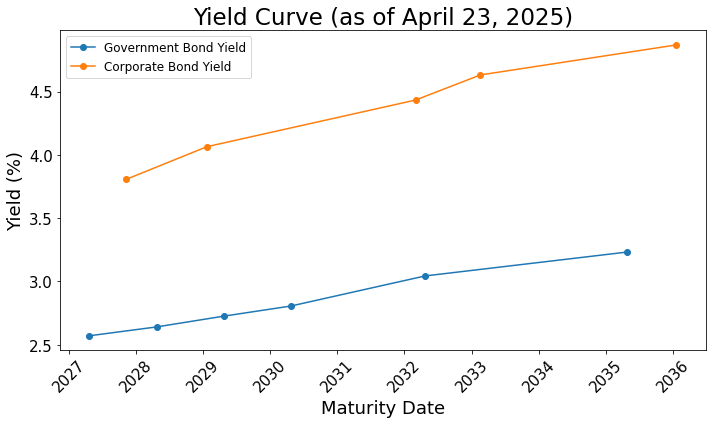

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime


#**#*#*#*#*#* Yield Curve 


maturity_dates_combined = [
    "2026-04-23", "2027-04-23", "2027-11-08", "2028-04-23", "2029-01-22", 
    "2029-04-23", "2030-04-23", "2032-03-01", "2032-04-23", "2033-02-17", 
    "2035-04-23", "2036-01-18"
]

yields_combined = [
    2.587, 2.571, 3.8060, 2.641, 4.0651, 
    2.726, 2.806, 4.4333, 3.044, 4.6318, 
    3.232, 4.8688
]

yields_r_free_with_zeros = [
    2.587, 2.571, None, 2.641, None, 
    2.726, 2.806, None, 3.044, None, 
    3.232, None
]

yields_with_zeros = [
    None, None, 3.8060, None, 4.0651, 
    None, None, 4.4333, None, 4.6318, 
    None, 4.8688
]

a = [i for i in yields_r_free_with_zeros if i is not None]
b = [i for i in yields_with_zeros if i is not None]
print('The difference in average yields is ', np.mean(a) - np.mean(b))

dates = [datetime.strptime(d, "%Y-%m-%d") for d in maturity_dates_combined]

corp_dates = [d for d, y in zip(dates, yields_with_zeros) if y is not None]
corp_yields = [y for y in yields_with_zeros if y is not None]

rf_dates = [d for d, y in zip(dates, yields_r_free_with_zeros) if y is not None]
rf_yields = [y for y in yields_r_free_with_zeros if y is not None]

plt.figure(figsize=(10, 6))
plt.plot(rf_dates[1:], rf_yields[1:], '-o', label="Government Bond Yield")
plt.plot(corp_dates, corp_yields, '-o', label="Corporate Bond Yield")

plt.legend(fontsize=12)
plt.xlabel("Maturity Date", fontsize=18)
plt.ylabel("Yield (%)", fontsize=18)
plt.title("Yield Curve (as of April 23, 2025)", fontsize=23)
plt.xticks(rotation=45, fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()



q:  0.9845210497239912
p_def:  0.015478950276008763


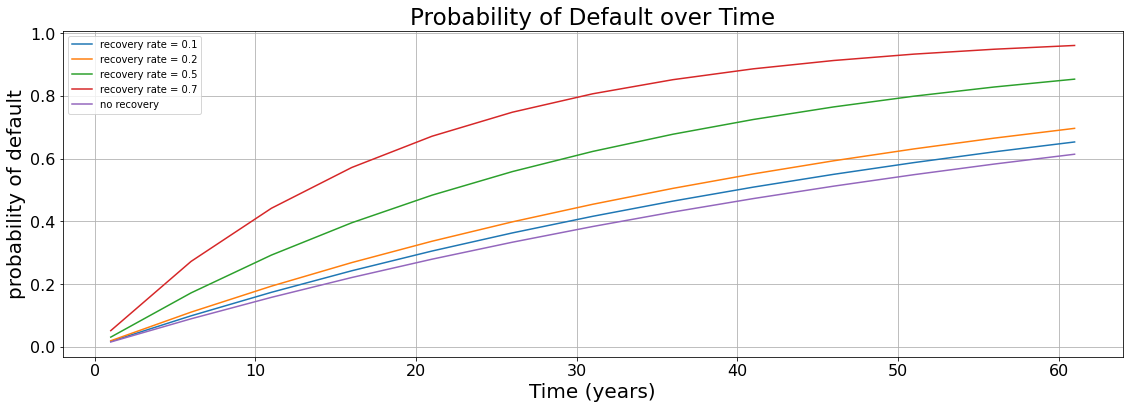

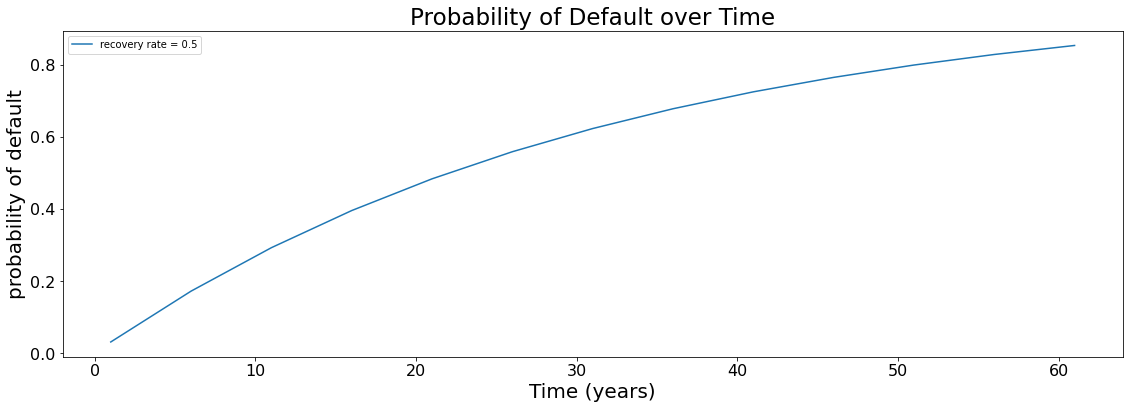

0.9845210497239912
0.015478950276008763


In [410]:


##*#*#**#*#*#*#**#*#*#*#*#* Recovery Rate  Model 4


import matplotlib.pyplot as plt
import numpy as np 

h = (3.7596 - 2.726) /100 
h = 0.0156

#*#*#**# if we do not take recovery rate into account 
q = np.exp(-h) # probability of solvency 

p_def = 1 - q #probab of default 

print( "q: ", q)
print( "p_def: ", p_def)

#*#*#*#
#if we take recovery rate rate into account 
recovery_list = [0.1, 0.2, 0.5, 0.7, 0.9]
q_with_recovery_list = []

for i in recovery_list:
    q_with_recovery = (np.exp(-h) - i ) / (1 - i) # probability of solvency # i = R here 
    q_with_recovery_list.append(q_with_recovery)



solvency_def_matrix = np.array([[q, 1-q], [0, 1]])

solvency_def_matrix_with_R_01 = np.array([[q_with_recovery_list[0], 1-q_with_recovery_list[0]], [0, 1]])
solvency_def_matrix_with_R_02 = np.array([[q_with_recovery_list[1], 1-q_with_recovery_list[1]], [0, 1]])
solvency_def_matrix_with_R_05 = np.array([[q_with_recovery_list[2], 1-q_with_recovery_list[2]], [0, 1]])
solvency_def_matrix_with_R_07 = np.array([[q_with_recovery_list[3], 1-q_with_recovery_list[3]], [0, 1]])
solvency_def_matrix_with_R_09 = np.array([[q_with_recovery_list[4], 1-q_with_recovery_list[4]], [0, 1]])


#taking powers of the matrices with recovery and no recovery 

list_probab_def_xyrs = []
list_probab_def_xyrs_R01 = []
list_probab_def_xyrs_R02 = []
list_probab_def_xyrs_R05 = []
list_probab_def_xyrs_R07 = []
list_probab_def_xyrs_R09 = []


list_yrs = list(range(1, 65, 5))

for i in list_yrs:
    probab_def_xyr = np.linalg.matrix_power(solvency_def_matrix, i)[0, 1]
    list_probab_def_xyrs.append(probab_def_xyr)

for i in list_yrs:
    probab_def_xyr_with_recovery = np.linalg.matrix_power(solvency_def_matrix_with_R_01, i)[0, 1]
    list_probab_def_xyrs_R01.append(probab_def_xyr_with_recovery)

for i in list_yrs:
    probab_def_xyr_with_recovery = np.linalg.matrix_power(solvency_def_matrix_with_R_02, i)[0, 1]
    list_probab_def_xyrs_R02.append(probab_def_xyr_with_recovery)

for i in list_yrs:
    probab_def_xyr_with_recovery = np.linalg.matrix_power(solvency_def_matrix_with_R_05, i)[0, 1]
    list_probab_def_xyrs_R05.append(probab_def_xyr_with_recovery)

for i in list_yrs:
    probab_def_xyr_with_recovery = np.linalg.matrix_power(solvency_def_matrix_with_R_07, i)[0, 1]
    list_probab_def_xyrs_R07.append(probab_def_xyr_with_recovery)

for i in list_yrs:
    probab_def_xyr_with_recovery = np.linalg.matrix_power(solvency_def_matrix_with_R_09, i)[0, 1]
    list_probab_def_xyrs_R09.append(probab_def_xyr_with_recovery)

plt.figure(figsize=(19, 6))
plt.plot(list_yrs, list_probab_def_xyrs_R01, label="recovery rate = 0.1")
plt.plot(list_yrs, list_probab_def_xyrs_R02, label="recovery rate = 0.2")
plt.plot(list_yrs, list_probab_def_xyrs_R05, label="recovery rate = 0.5")
plt.plot(list_yrs, list_probab_def_xyrs_R07, label="recovery rate = 0.7")
# plt.plot(list_yrs, list_probab_def_xyrs_R09, label="recovery rate = 0.9")

plt.plot(list_yrs, list_probab_def_xyrs, label="no recovery")
plt.grid(True)
plt.legend()
plt.xlabel("Time (years)", fontsize=20)
plt.ylabel("probability of default", fontsize=20)
plt.title("Probability of Default over Time", fontsize=23)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

plt.figure(figsize=(19, 6))
plt.plot(list_yrs, list_probab_def_xyrs_R05, label="recovery rate = 0.5")
plt.legend()
plt.xlabel("Time (years)", fontsize=20)
plt.ylabel("probability of default", fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.title("Probability of Default over Time", fontsize=23)
plt.show()


h

print(q)
print(1-q)

In [ ]:




######## Merton Model Work  ------------------------------------------------------------

# Market Cap -- 64.551B - Underlying Price
# Total Debt (Book Value) -- 19.184 B - Strike Price
# Volatility of Stock -- 5.79% - avg fo the rolling volatility of the stock over past 12 months 
# Risk Free Rate -- 2.726% - this is the current estimates for the yield curve for 4 year bond froom this website, https://www.worldgovernmentbonds.com/country/canada/
# Dividend Yield -- 0.95% 


def calculate_asset_volatility(sigma_s, S, V, delta):
    return (sigma_s * S * delta) / V


####    FIRST YR

print("__________________Values for default probability in 1 yr")

# ###            first iteration      

sigma_s = 0.22 # Volatility of Stock 
S = 45.277     # Option Price 
V = 64.551     # Market Cap (value of assets)
delta = 0.991  # Delta from the image

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22 # Volatility of Stock 
S = 45.277     # Option Price 
V = 64.551     # Market Cap (value of assets)
delta = 0.991  # Delta from the image

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)


### 5th year

print("__________________Values for default probability in 5 yrs")

# ###            first iteration      

sigma_s = 0.22 # Volatility of Stock 
S = 44.856     # Option Price 
V = 64.551     # Market Cap (value of assets)
delta = 0.952  # Delta from the image

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22 # Volatility of Stock 
S = 44.837     # Option Price 
V = 64.551     # Market Cap (value of assets)
delta = 0.954  # Delta from the image

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)





#### 10th YR

print("__________________Values for default probability in 10 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 44.293
V = 64.551
delta = 0.901

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 44.131
V = 64.551
delta = 0.909

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

# ###            third iteration      

sigma_s = 0.22
S = 44.131
V = 64.551
delta = 0.909

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility third iteration:", asset_volatility)




### 15th year

print("__________________Values for default probability in 15 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 43.629
V = 64.551
delta = 0.852

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 43.283
V = 64.551
delta = 0.867

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

# ###            third iteration      

sigma_s = 0.22
S = 43.283
V = 64.551
delta = 0.867

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility third iteration:", asset_volatility)

#### 20th YR

print("__________________Values for default probability in 20 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 42.336
V = 64.551
delta = 0.825

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 42.318
V = 64.551
delta = 0.826

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

### 25th year

print("__________________Values for default probability in 25 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 41.881
V = 64.551
delta = 0.773

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 41.263
V = 64.551
delta = 0.788

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

#### 30th YR

print("__________________Values for default probability in 30 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 40.830
V = 64.551
delta = 0.737

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 40.139
V = 64.551
delta = 0.752

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

### 35th year

print("__________________Values for default probability in 35 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 38.972
V = 64.551
delta = 0.717

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 38.966
V = 64.551
delta = 0.717

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

#### 40th YR

print("__________________Values for default probability in 40 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 38.498
V = 64.551
delta = 0.671

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 37.759
V = 64.551
delta = 0.684

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

### 45th year

print("__________________Values for default probability in 45 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 37.261
V = 64.551
delta = 0.641

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 36.531
V = 64.551
delta = 0.652

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

#### 50th YR

print("__________________Values for default probability in 50 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 35.999
V = 64.551
delta = 0.612

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 35.293
V = 64.551
delta = 0.622

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

# ###            third iteration      

sigma_s = 0.22
S = 35.293
V = 64.551
delta = 0.622

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility third iteration:", asset_volatility)

### 55th year

print("__________________Values for default probability in 55 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 34.727
V = 64.551
delta = 0.584

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 34.054
V = 64.551
delta = 0.593

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

# ###            third iteration      

sigma_s = 0.22
S = 34.054
V = 64.551
delta = 0.593

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility third iteration:", asset_volatility)

#### 60th YR

print("__________________Values for default probability in 60 yrs")

# ###            first iteration      

sigma_s = 0.22
S = 33.455
V = 64.551
delta = 0.558

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility first iteration:", asset_volatility)

# ###            second iteration      

sigma_s = 0.22
S = 32.821
V = 64.551
delta = 0.566

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility second iteration:", asset_volatility)

# ###            third iteration      

sigma_s = 0.22
S = 32.821
V = 64.551
delta = 0.566

asset_volatility = calculate_asset_volatility(sigma_s, S, V, delta)
print("Calculated Asset Volatility third iteration:", asset_volatility)



__________________Values for default probability in 1 yr
Calculated Asset Volatility first iteration: 0.15292236433207854
Calculated Asset Volatility second iteration: 0.15292236433207854
__________________Values for default probability in 5 yrs
Calculated Asset Volatility first iteration: 0.1455382664869638
Calculated Asset Volatility second iteration: 0.1457822428777246
__________________Values for default probability in 10 yrs
Calculated Asset Volatility first iteration: 0.13601274124335797
Calculated Asset Volatility second iteration: 0.1367185230283032
Calculated Asset Volatility third iteration: 0.1367185230283032
__________________Values for default probability in 15 yrs
Calculated Asset Volatility first iteration: 0.1266877315610912
Calculated Asset Volatility second iteration: 0.12789576334990937
Calculated Asset Volatility third iteration: 0.12789576334990937
__________________Values for default probability in 20 yrs
Calculated Asset Volatility first iteration: 0.119037412278

No handles with labels found to put in legend.


d2:  2.3257553091842538
CDF value : 0.010015804012405604
the PD after 1yr is  4.580569085002022e-16
the PD after 5yrs is  3.4913761149283395e-05
the PD after 10yrs is  0.0006378970131810278
the PD after 15yrs is  0.0012337113483989418
the PD after 20yrs is  0.0012012220636171793
the PD after 25yrs is  0.0008351036573071039
the PD after 30yrs is  0.0004467256455001745
the PD after 35yrs is  0.00018066450962764329
the PD after 40yrs is  5.6454685780572756e-05
the PD after 45yrs is  1.2923636288093757e-05
the PD after 50yrs is  2.046547089408327e-06
the PD after 55yrs is  2.080758179450182e-07
the PD after 60yrs is  1.3085681340172218e-08


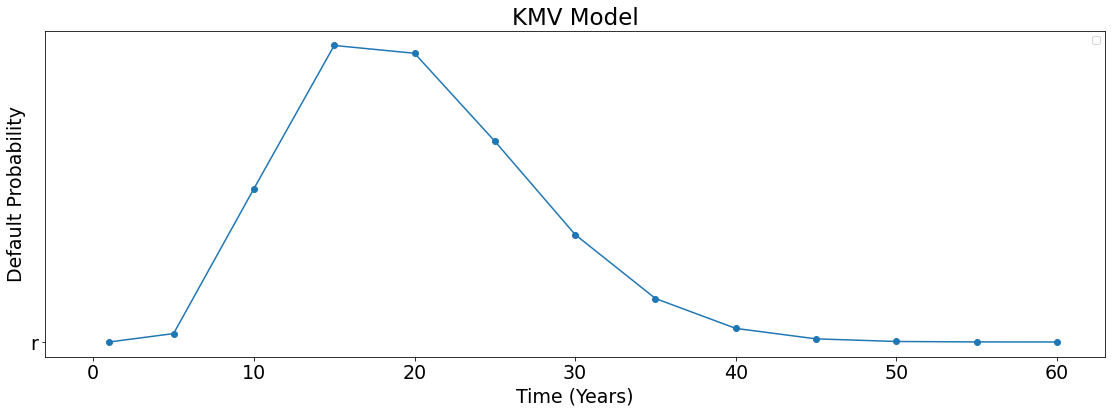

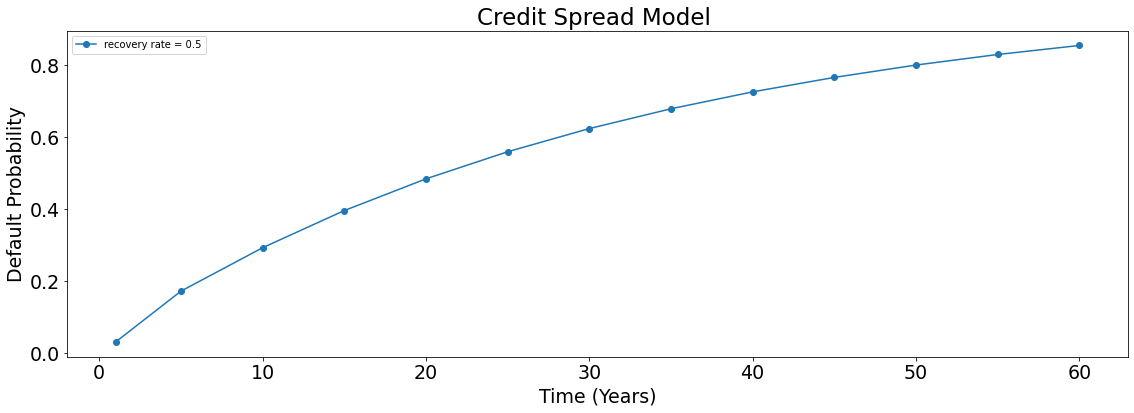

In [408]:
debt = (1122.0 * 200e3) + (1140.7 * 200e3) + (1086.7 * 300e3) + (1084.5 * 175e3) + (1070.5 * 100e3)

debt


import numpy as np

def compute_d2(S0, K, r, sigma, T, t=0):

    tau = T - t
    numerator = np.log(S0 / K) + (r - 0.5 * sigma**2) * tau
    denominator = sigma * np.sqrt(tau)

    return numerator / denominator

d2 = compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.13, T= 60)

print('d2: ', d2)

from scipy.stats import norm

cdf_value = norm.cdf(-d2)
print("CDF value :", cdf_value)

def compute_cdf(d2):
    return norm.cdf(-d2)




PD_1yr = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1529, T= 1))
PD_5yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1458, T= 5))
PD_10yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1367, T= 10))
PD_15yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1279, T= 15))
PD_20yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1191, T= 20))
PD_25yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1108, T= 25))
PD_30yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.1029, T= 30))
PD_35yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0952, T= 35))
PD_40yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0880, T= 40))
PD_45yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0812, T= 45))
PD_50yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0748, T= 50))
PD_55yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0688, T= 55))
PD_60yrs = compute_cdf(compute_d2(S0= 64.551, K= 19.184, r= 0.02726, sigma= 0.0633, T= 60))

print('the PD after 1yr is ', PD_1yr)
print('the PD after 5yrs is ', PD_5yrs)
print('the PD after 10yrs is ', PD_10yrs)
print('the PD after 15yrs is ', PD_15yrs)
print('the PD after 20yrs is ', PD_20yrs)
print('the PD after 25yrs is ', PD_25yrs)
print('the PD after 30yrs is ', PD_30yrs)
print('the PD after 35yrs is ', PD_35yrs)
print('the PD after 40yrs is ', PD_40yrs)
print('the PD after 45yrs is ', PD_45yrs)
print('the PD after 50yrs is ', PD_50yrs)
print('the PD after 55yrs is ', PD_55yrs)
print('the PD after 60yrs is ', PD_60yrs)

list_yrs = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
list_pd = [PD_1yr, PD_5yrs, PD_10yrs, PD_15yrs, PD_20yrs, PD_25yrs, PD_30yrs, PD_35yrs, PD_40yrs, PD_45yrs, PD_50yrs, PD_55yrs, PD_60yrs]  

plt.figure(figsize=(19, 6))
plt.plot(list_yrs, list_pd, '-o','r')
plt.title('KMV Model', fontsize=23)
plt.xlabel('Time (Years)', fontsize=19)
plt.xticks(fontsize=19)
plt.yticks(fontsize=19)
plt.ylabel('Default Probability', fontsize=19)
plt.legend()
plt.show()

plt.figure(figsize=(19, 6))
plt.plot(list_yrs, list_probab_def_xyrs_R05, '-o',label="recovery rate = 0.5")
plt.legend()
plt.xlabel("Time (Years)", fontsize=19)
plt.xticks(fontsize=19)
plt.yticks(fontsize=19)
plt.ylabel("Default Probability", fontsize=19)
plt.title("Credit Spread Model ", fontsize=23)
plt.show()
